# **Data Understanding**

In [4]:
import pandas as pd
import numpy as np

In [6]:
#Load the dataset
df = pd.read_csv("Rice_Cammeo_Osmancik.csv")

In [7]:
#Display first 5 rows
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3810
Number of columns: 8


In [9]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent', 'Class']


In [10]:
df.dtypes

,0
Area,float64
Perimeter,float64
Major_Axis_Length,float64
Minor_Axis_Length,float64
Eccentricity,float64
Convex_Area,float64
Extent,float64
Class,object


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(7), object(1)
memory usage: 238.3+ KB
None


In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64


In [13]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
df[df.duplicated()]

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class


In [16]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [17]:
df["Class"]

,Class
0,Cammeo
1,Cammeo
2,Cammeo
3,Cammeo
4,Cammeo
...,...
3805,Osmancik
3806,Osmancik
3807,Osmancik
3808,Osmancik


In [18]:
print(df["Class"].unique())

['Cammeo' 'Osmancik']


In [19]:
print(df["Class"].value_counts())

Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


In [20]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
Osmancik    57.217848
Cammeo      42.782152
Name: proportion, dtype: float64


In [21]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Area,float64,0,2828
Perimeter,float64,0,3738
Major_Axis_Length,float64,0,3808
Minor_Axis_Length,float64,0,3804
Eccentricity,float64,0,3803
Convex_Area,float64,0,2857
Extent,float64,0,3804
Class,object,0,2


# **Visualizations**

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

/tmp/ipykernel_2409/1759821484.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="Set2")


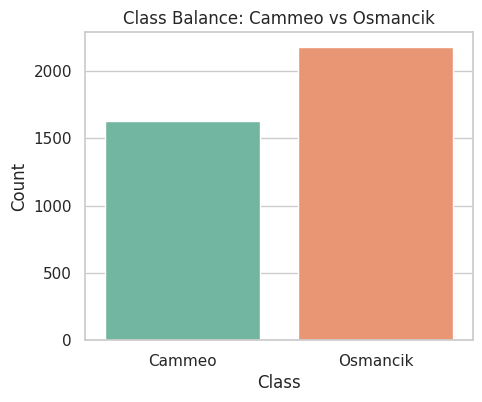

In [23]:
#Class Balance
plt.figure(figsize=(5,4))
sns.countplot(x="Class", data=df, palette="Set2")
plt.title("Class Balance: Cammeo vs Osmancik")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

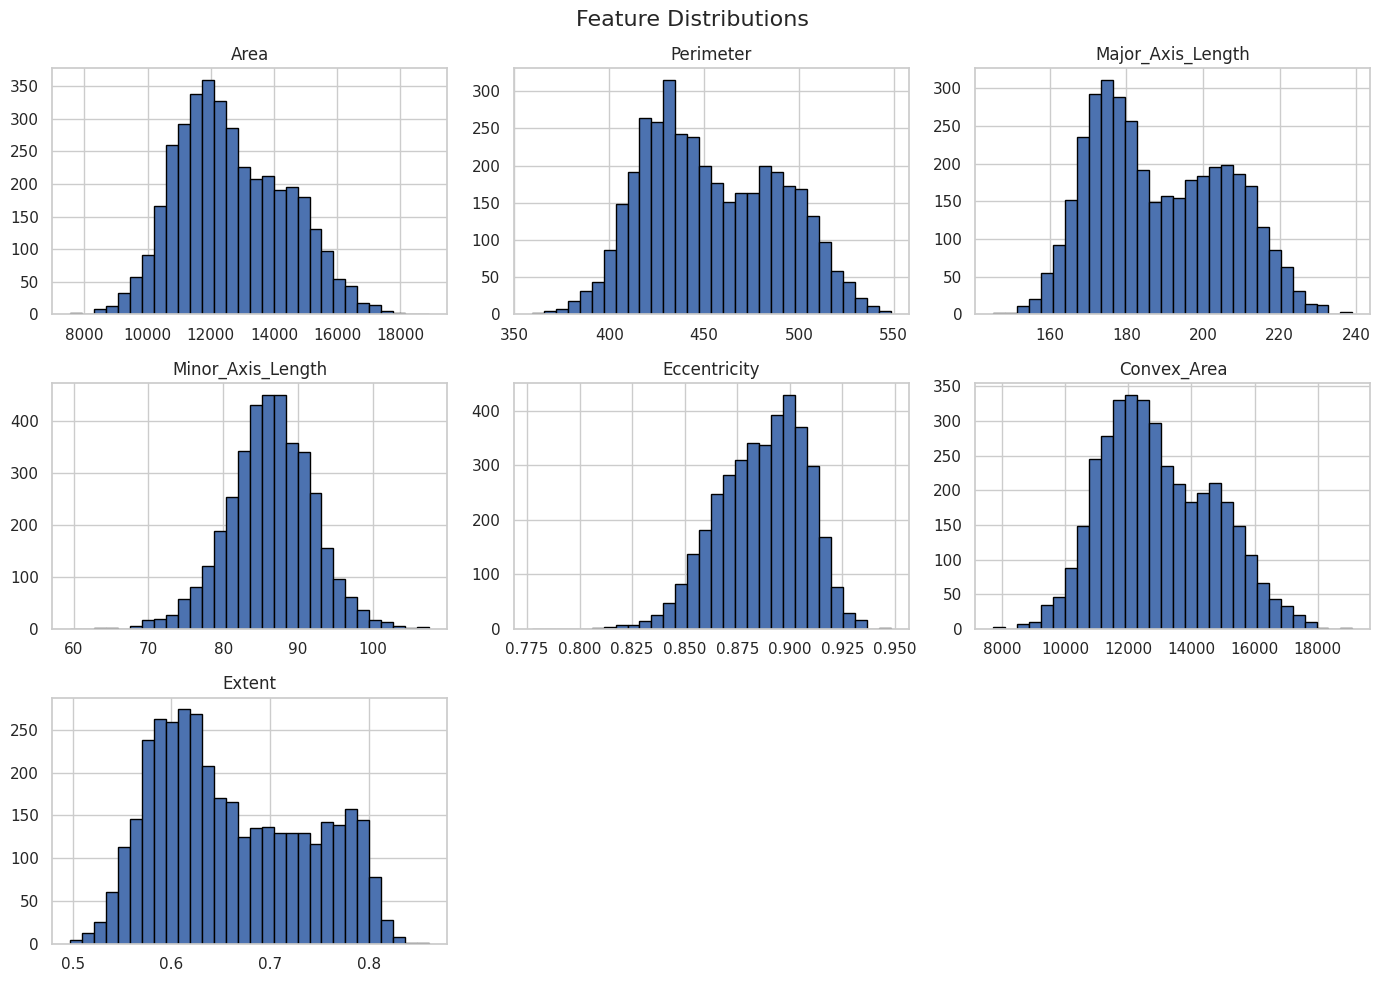

In [24]:
#Feature distributions (histograms)
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

df[numeric_cols].hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

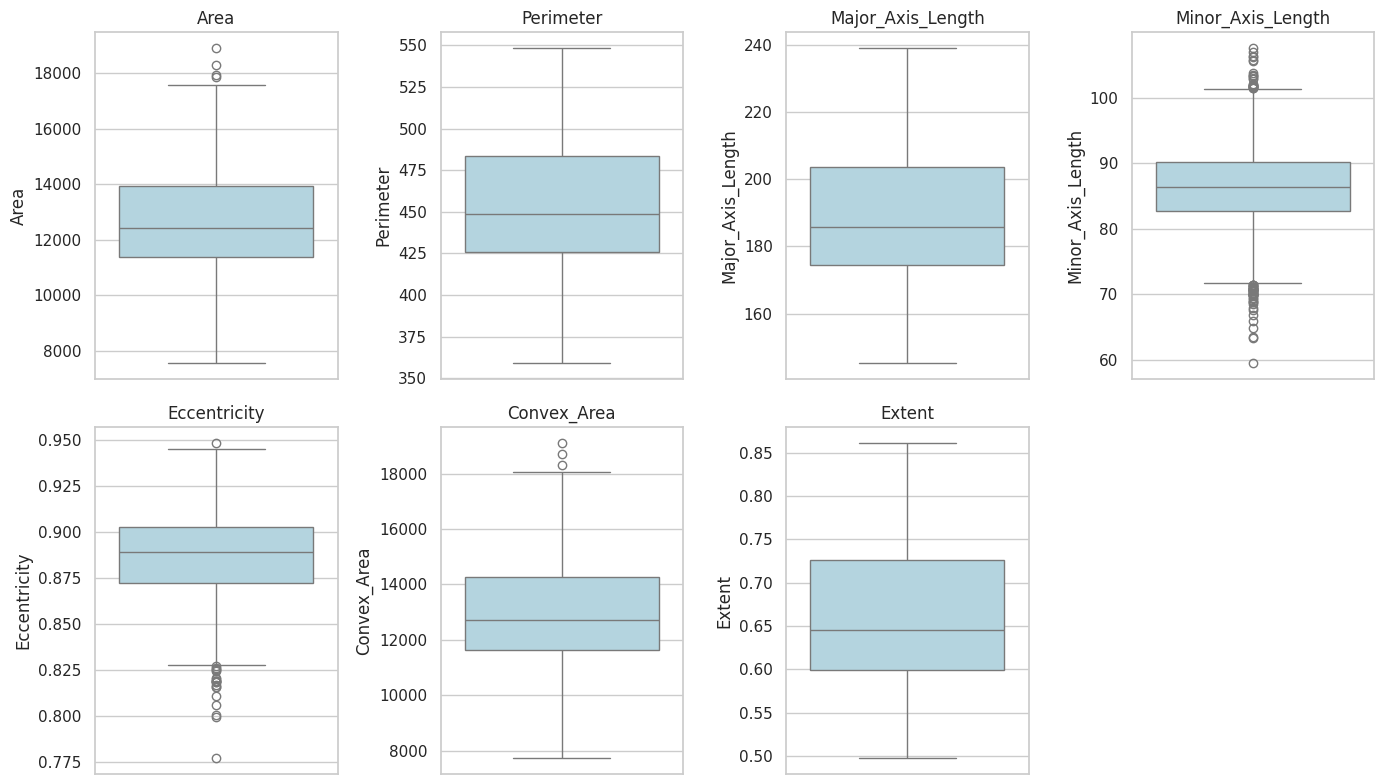

In [25]:
#Boxplots to check for outliers (all features)
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color="lightblue")
    plt.title(col)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2409/1134711309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=col, data=df, palette="Set2")
/tmp/ipykernel_2409/1134711309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=col, data=df, palette="Set2")
/tmp/ipykernel_2409/1134711309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=col, data=df, palette="Set2")
/tmp/ipykernel_2409/1134711309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

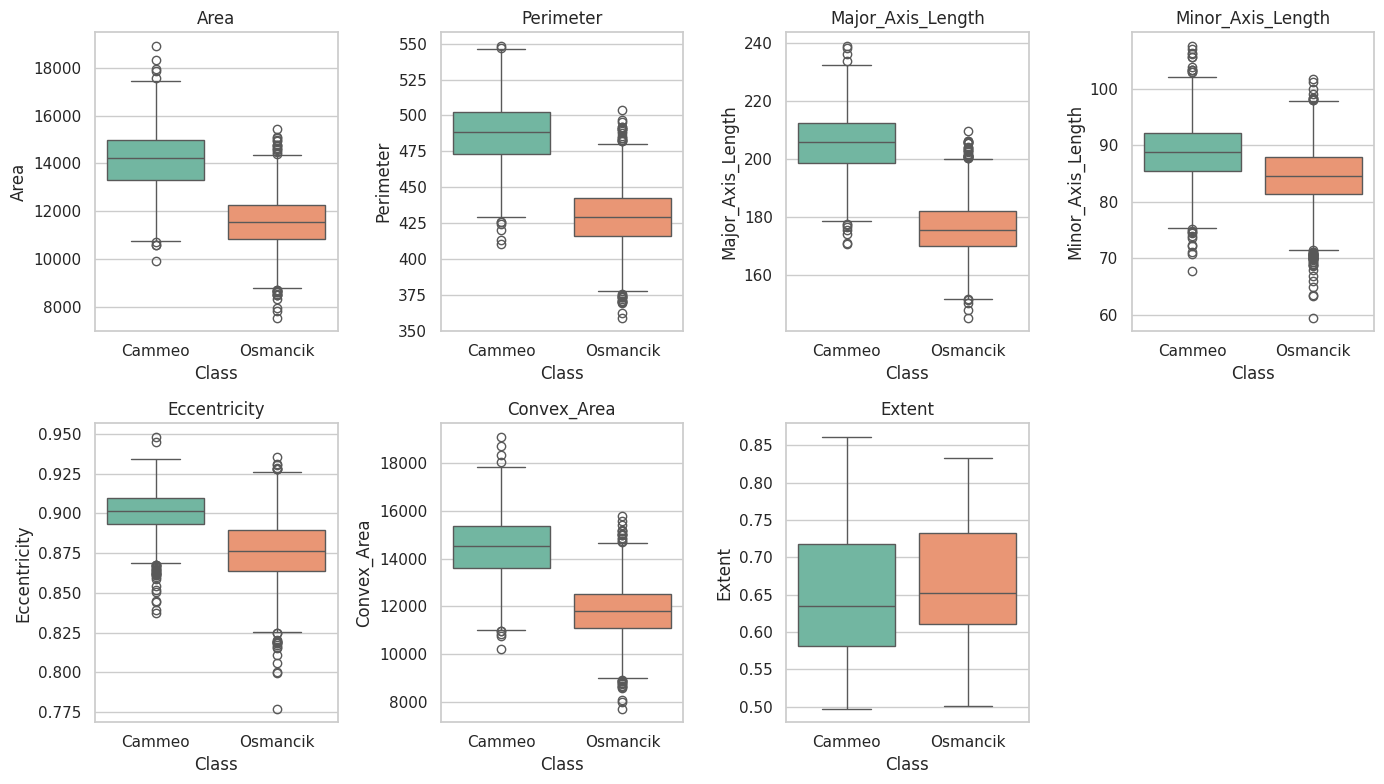

In [26]:
#Feature relationships with the target (boxplots by class)
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x="Class", y=col, data=df, palette="Set2")
    plt.title(col)
plt.tight_layout()
plt.show()

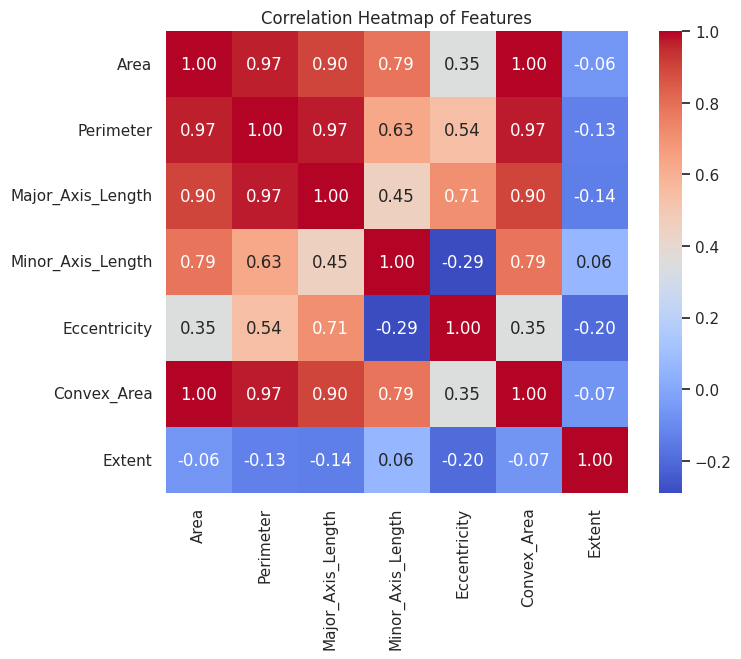

In [27]:
#Correlation heatmap between features
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Features")
plt.show()

In [28]:
#Outlier count per feature (IQR method)
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count"])
outlier_df["Outlier %"] = (outlier_df["Outlier Count"] / len(df) * 100).round(2)
outlier_df

,Outlier Count,Outlier %
Area,4,0.10
Perimeter,0,0.00
Major_Axis_Length,0,0.00
Minor_Axis_Length,65,1.71
Eccentricity,21,0.55
Convex_Area,3,0.08
Extent,0,0.00


## EDA Insight Log

**Dataset:** 3,810 rice grains, 7 numeric morphological features, binary target (Cammeo / Osmancik). No missing values, no duplicates.

**Class balance:** 57.2% Osmancik vs 42.8% Cammeo — a mild imbalance, not severe. Stratified train/test splitting should be enough; no resampling needed.

**Distributions:** Most features (Area, Perimeter, Major/Minor Axis Length, Convex Area) are right-skewed with a small number of large grains pulling the tail. Eccentricity and Extent are closer to symmetric.

**Outliers:** Present in most features (see IQR table above) but relatively low in count relative to 3,810 rows. Likely genuine large/small grains rather than data entry errors, since Area, Perimeter, and Convex_Area move together consistently — worth flagging as 'keep but note' rather than removing outright, and confirming with the group before deciding.

**Correlation:** Area, Perimeter, Convex_Area, and Major_Axis_Length are highly correlated with each other (expected, since they all scale with grain size). This is useful to know before modeling — models like Logistic Regression can be sensitive to this multicollinearity, while tree-based models (Decision Tree, Random Forest) are more robust to it.

**Separation by class:** Boxplots by class show Major_Axis_Length and Eccentricity appear to separate Cammeo and Osmancik most clearly — Cammeo grains tend to be longer and more elongated. This is a useful early signal for the feature-importance secondary lens.

**Handoff to preprocessing:** No missing values or duplicates to handle. Main preprocessing decisions needed: (1) whether/how to treat outliers, (2) feature scaling given the very different ranges (Area in thousands vs Extent 0–1), (3) stratified train/test split given the class imbalance.